<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [3]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


1. DEFINICIÓN DEL PROBLEMA
Objetivo: predecir 'target' (valor medio de vivienda en USD x100k)
a partir de características demográficas y geográficas.

Dimensiones: (20640, 9)
Variables predictoras: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

2. ESTADÍSTICA DESCRIPTIVA
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        0.500      1.000      0.846      0.333       3.000      0.692   
25%        2.563     18.000      4.441      1.006     787.000      2.430   
50%        3.535     29.000      5.229      1.049    1166.000      2.818   
75%        4.743     37.000      6.052      1.100    1725.000      3.282   
max       15.000     52.000    141.909     34.067   35682.000   124

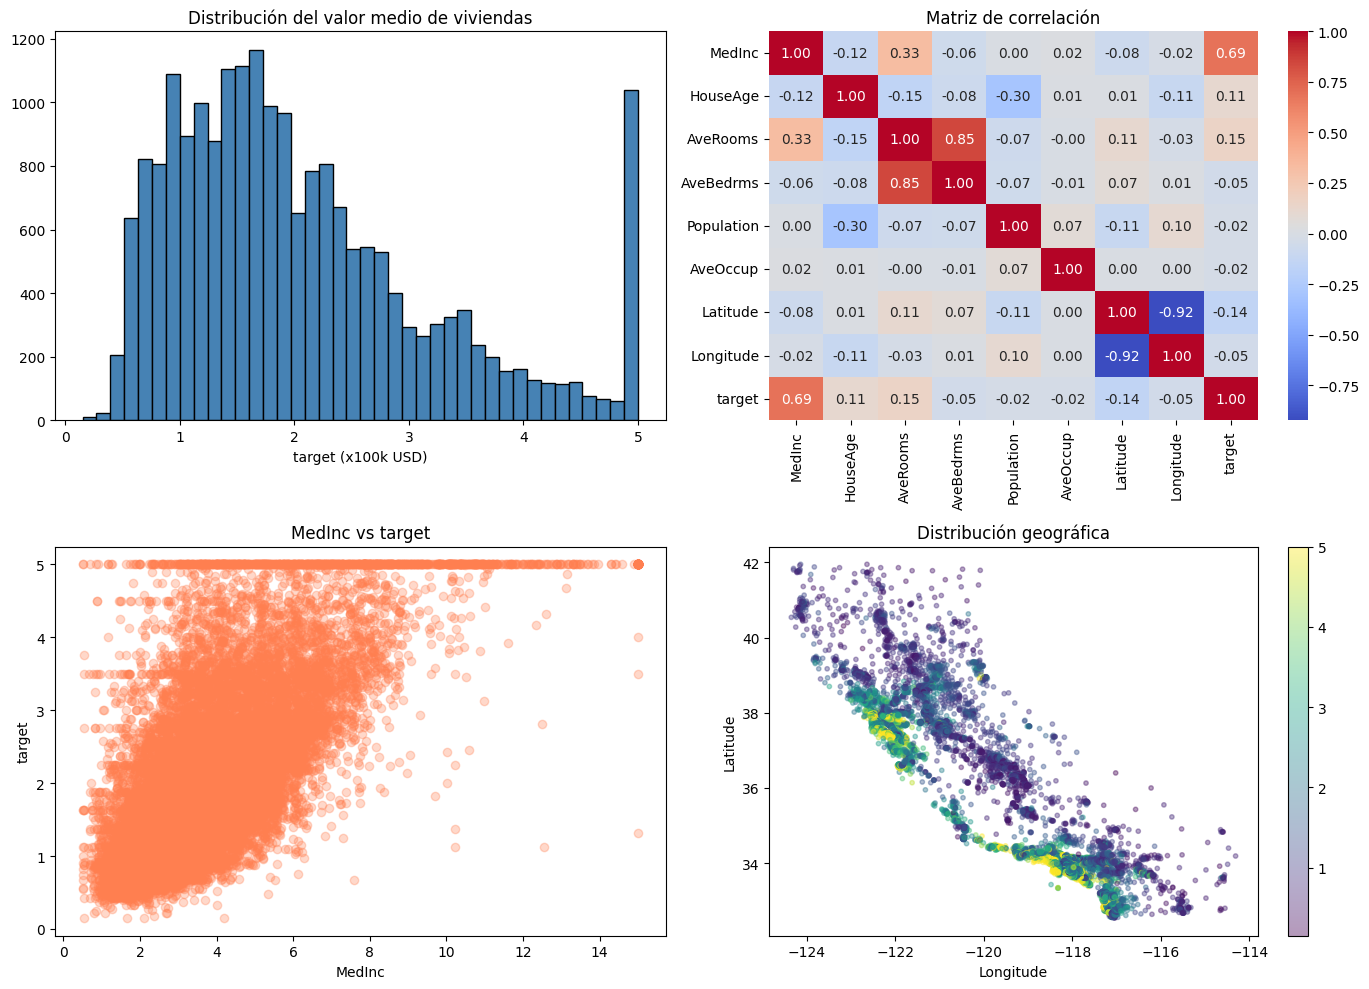


6. COMPARACIÓN DE MODELOS
           modelo    mae   rmse    mape     r2  tiempo_s
    Random Forest 0.3276 0.5055 18.9367 0.8050    1.3974
Gradient Boosting 0.3717 0.5422 21.5266 0.7756    2.6759
              KNN 0.4403 0.6493 24.5418 0.6783    0.0048
Linear Regression 0.5332 0.7456 31.9522 0.5758    0.0025
            Ridge 0.5332 0.7456 31.9512 0.5758    0.0036
            Lasso 0.6222 0.8244 39.9724 0.4814    0.0018


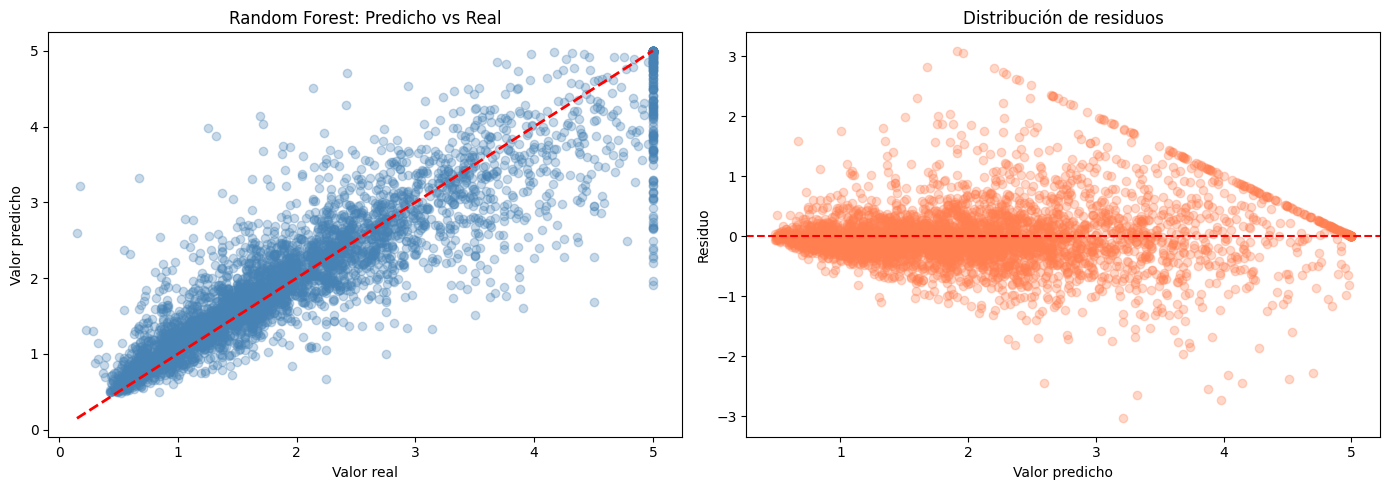


8. CONCLUSIONES (Regresión)
- Mejor modelo: Random Forest
- Los modelos basados en árboles (Random Forest, GB) superan a los lineales,
  porque la relación entre features y precio NO es estrictamente lineal.
- 'MedInc' es la variable con mayor correlación con el target.
- Hay un techo evidente en y=5.0 (target capeado), que limita el ajuste.


In [4]:
# =====================================================
# REGRESIÓN: California Housing
# =====================================================
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# 1. Definición del problema
print("=" * 60)
print("1. DEFINICIÓN DEL PROBLEMA")
print("=" * 60)
print("Objetivo: predecir 'target' (valor medio de vivienda en USD x100k)")
print("a partir de características demográficas y geográficas.")
print(f"\nDimensiones: {housing.shape}")
print(f"Variables predictoras: {list(housing.columns[:-1])}")

# 2. Estadística descriptiva
print("\n" + "=" * 60)
print("2. ESTADÍSTICA DESCRIPTIVA")
print("=" * 60)
print(housing.describe().round(3))
print(f"\nValores nulos: {housing.isnull().sum().sum()}")

# 3. Visualización descriptiva
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma del target
axes[0, 0].hist(housing['target'], bins=40, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribución del valor medio de viviendas')
axes[0, 0].set_xlabel('target (x100k USD)')

# Mapa de calor de correlaciones
sns.heatmap(housing.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Matriz de correlación')

# Ingreso medio vs valor
axes[1, 0].scatter(housing['MedInc'], housing['target'], alpha=0.3, color='coral')
axes[1, 0].set_xlabel('MedInc')
axes[1, 0].set_ylabel('target')
axes[1, 0].set_title('MedInc vs target')

# Distribución geográfica
sc = axes[1, 1].scatter(housing['Longitude'], housing['Latitude'],
                         c=housing['target'], cmap='viridis', alpha=0.4, s=10)
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].set_title('Distribución geográfica')
plt.colorbar(sc, ax=axes[1, 1])
plt.tight_layout()
plt.show()

# 4. Preprocesamiento
X = housing.drop(columns='target')
y = housing['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Selección de modelos: probamos varios modelos distintos
modelos = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 6. Métricas y comparación
resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    t0 = time.time()
    modelo.fit(X_train_scaled, y_train)
    tiempo = time.time() - t0
    y_pred = modelo.predict(X_test_scaled)
    predicciones[nombre] = y_pred

    df_eval = pd.DataFrame({'y': y_test.values, 'yhat': y_pred})
    metricas = regression_metrics(df_eval)
    metricas['r2'] = round(r2_score(y_test, y_pred), 4)
    metricas['tiempo_s'] = round(tiempo, 4)
    metricas['modelo'] = nombre
    resultados.append(metricas)

df_resultados = pd.concat(resultados, ignore_index=True)
df_resultados = df_resultados[['modelo', 'mae', 'rmse', 'mape', 'r2', 'tiempo_s']].sort_values('rmse')
print("\n" + "=" * 60)
print("6. COMPARACIÓN DE MODELOS")
print("=" * 60)
print(df_resultados.to_string(index=False))

# 7. Visualización de resultados del mejor modelo
mejor_modelo = df_resultados.iloc[0]['modelo']
y_pred_mejor = predicciones[mejor_modelo]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_mejor, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'{mejor_modelo}: Predicho vs Real')

residuos = y_test - y_pred_mejor
axes[1].scatter(y_pred_mejor, residuos, alpha=0.3, color='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Distribución de residuos')
plt.tight_layout()
plt.show()

# 8. Conclusiones
print("\n" + "=" * 60)
print("8. CONCLUSIONES (Regresión)")
print("=" * 60)
print(f"- Mejor modelo: {mejor_modelo}")
print(f"- Los modelos basados en árboles (Random Forest, GB) superan a los lineales,")
print(f"  porque la relación entre features y precio NO es estrictamente lineal.")
print(f"- 'MedInc' es la variable con mayor correlación con el target.")
print(f"- Hay un techo evidente en y=5.0 (target capeado), que limita el ajuste.")

## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [5]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [7]:
# informacion de las columnas
digits_dict.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [8]:
# informacion del target
digits_dict["target"]

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [9]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

,c00,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c55,c56,c57,c58,c59,c60,c61,c62,c63,target
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

INFORMACIÓN GENERAL
Dimensiones: (1797, 65)
Memoria usada: 912.67 KB

Tipos de datos:
int64    65
Name: count, dtype: int64

Valores nulos: 0

DISTRIBUCIÓN DE CLASES
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


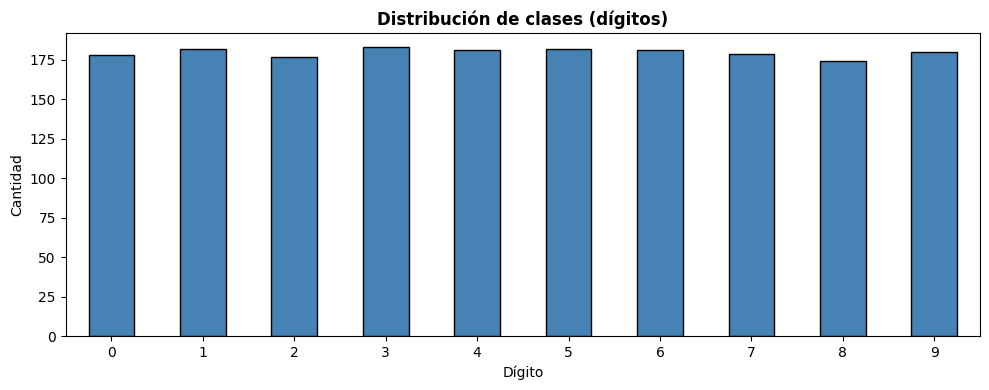


DISTRIBUCIÓN DE VALORES DE PIXELES
      mean   std  min   max
c00   0.00  0.00  0.0   0.0
c01   0.30  0.91  0.0   8.0
c02   5.20  4.75  0.0  16.0
c03  11.84  4.25  0.0  16.0
c04  11.85  4.29  0.0  16.0
c05   5.78  5.67  0.0  16.0
c06   1.36  3.33  0.0  16.0
c07   0.13  1.04  0.0  15.0
c08   0.01  0.09  0.0   2.0
c09   1.99  3.20  0.0  16.0

Los valores de los píxeles están en el rango [0, 16] (escala de grises).
Las clases están razonablemente balanceadas (~180 muestras por clase).


In [10]:
# Ejercicio 1: Análisis exploratorio del dataset Digits

print("=" * 60)
print("INFORMACIÓN GENERAL")
print("=" * 60)
print(f"Dimensiones: {digits.shape}")
print(f"Memoria usada: {digits.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\nTipos de datos:\n{digits.dtypes.value_counts()}")
print(f"\nValores nulos: {digits.isnull().sum().sum()}")

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 60)
print(digits['target'].value_counts().sort_index())

# Visualizar balance de clases
fig, ax = plt.subplots(figsize=(10, 4))
digits['target'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
ax.set_title('Distribución de clases (dígitos)', fontweight='bold')
ax.set_xlabel('Dígito')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE VALORES DE PIXELES")
print("=" * 60)
print(digits.iloc[:, :-1].describe().T[['mean', 'std', 'min', 'max']].head(10).round(2))
print("\nLos valores de los píxeles están en el rango [0, 16] (escala de grises).")
print("Las clases están razonablemente balanceadas (~180 muestras por clase).")

### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [11]:
digits_dict["images"][0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

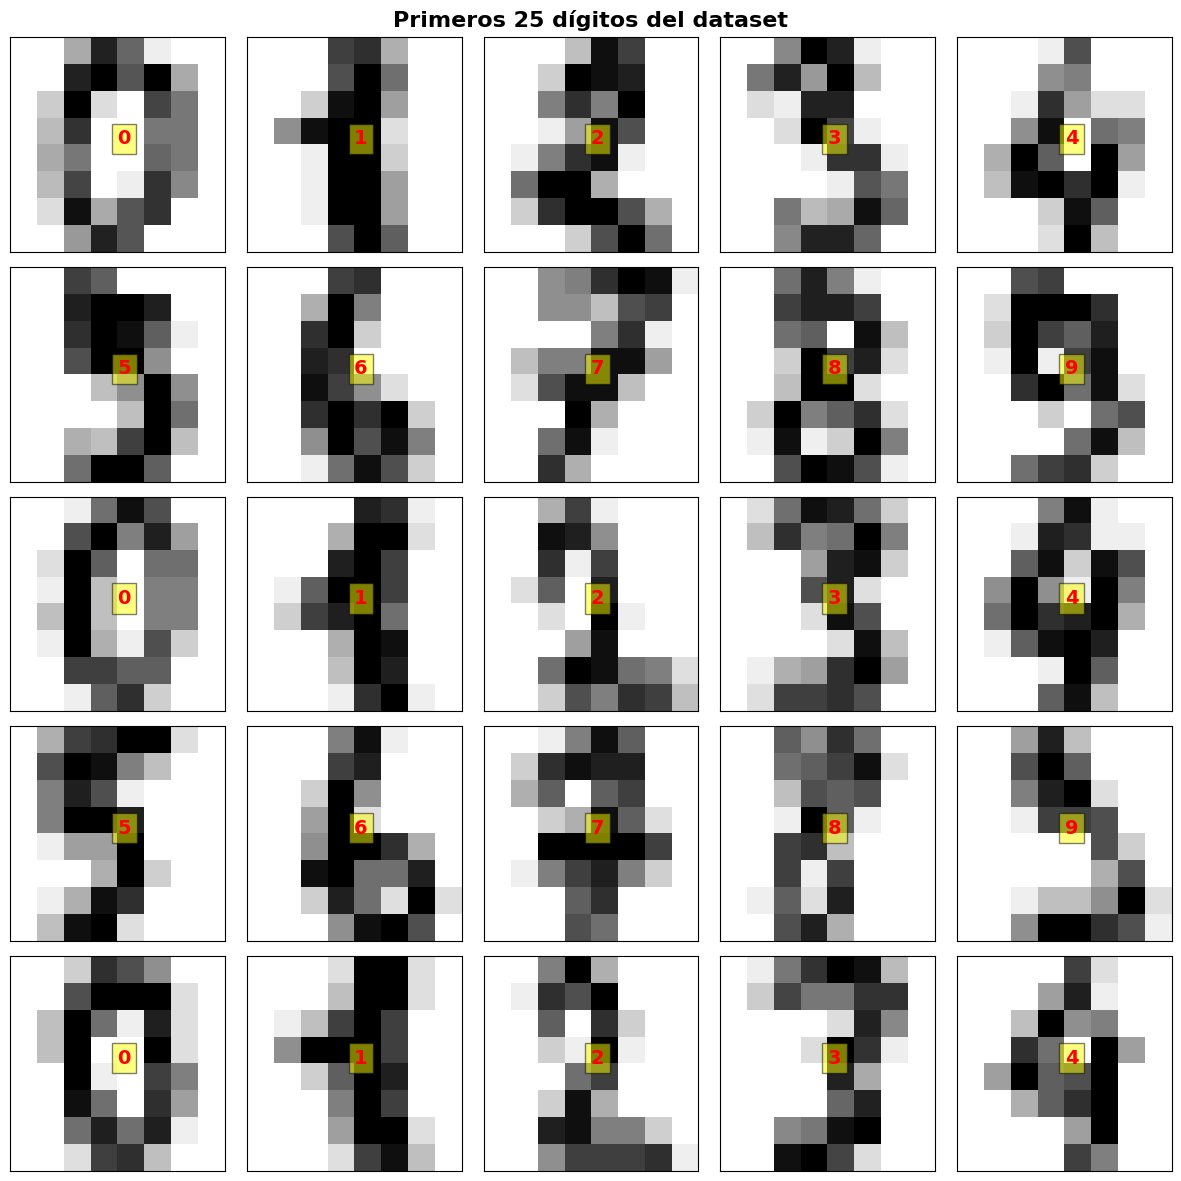

In [12]:
# Ejercicio 2: Visualización de los primeros 25 dígitos
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

for i in range(nx * ny):
    row, col = i // ny, i % ny
    image = digits_dict["images"][i]
    label = digits_dict["target"][i]

    axs[row, col].imshow(image, cmap='gray_r', interpolation='nearest')
    axs[row, col].text(0.5, 0.5, str(label), fontsize=14, color='red',
                       fontweight='bold', transform=axs[row, col].transAxes,
                       bbox=dict(facecolor='yellow', alpha=0.5))
    axs[row, col].set_xticks([])
    axs[row, col].set_yticks([])

plt.suptitle('Primeros 25 dígitos del dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?


In [13]:
# features, target

X = digits.drop(columns="target").values
y = digits["target"].values

Tamaño entrenamiento: 1437
Tamaño test: 360



COMPARACIÓN DE MODELOS DE CLASIFICACIÓN
             modelo  accuracy  precision  recall     f1  tiempo_s
                SVM    0.9750     0.9759  0.9750 0.9749    0.1777
Logistic Regression    0.9722     0.9724  0.9722 0.9722    0.0115
                KNN    0.9639     0.9648  0.9639 0.9636    0.0003
      Random Forest    0.9639     0.9644  0.9639 0.9636    0.0886


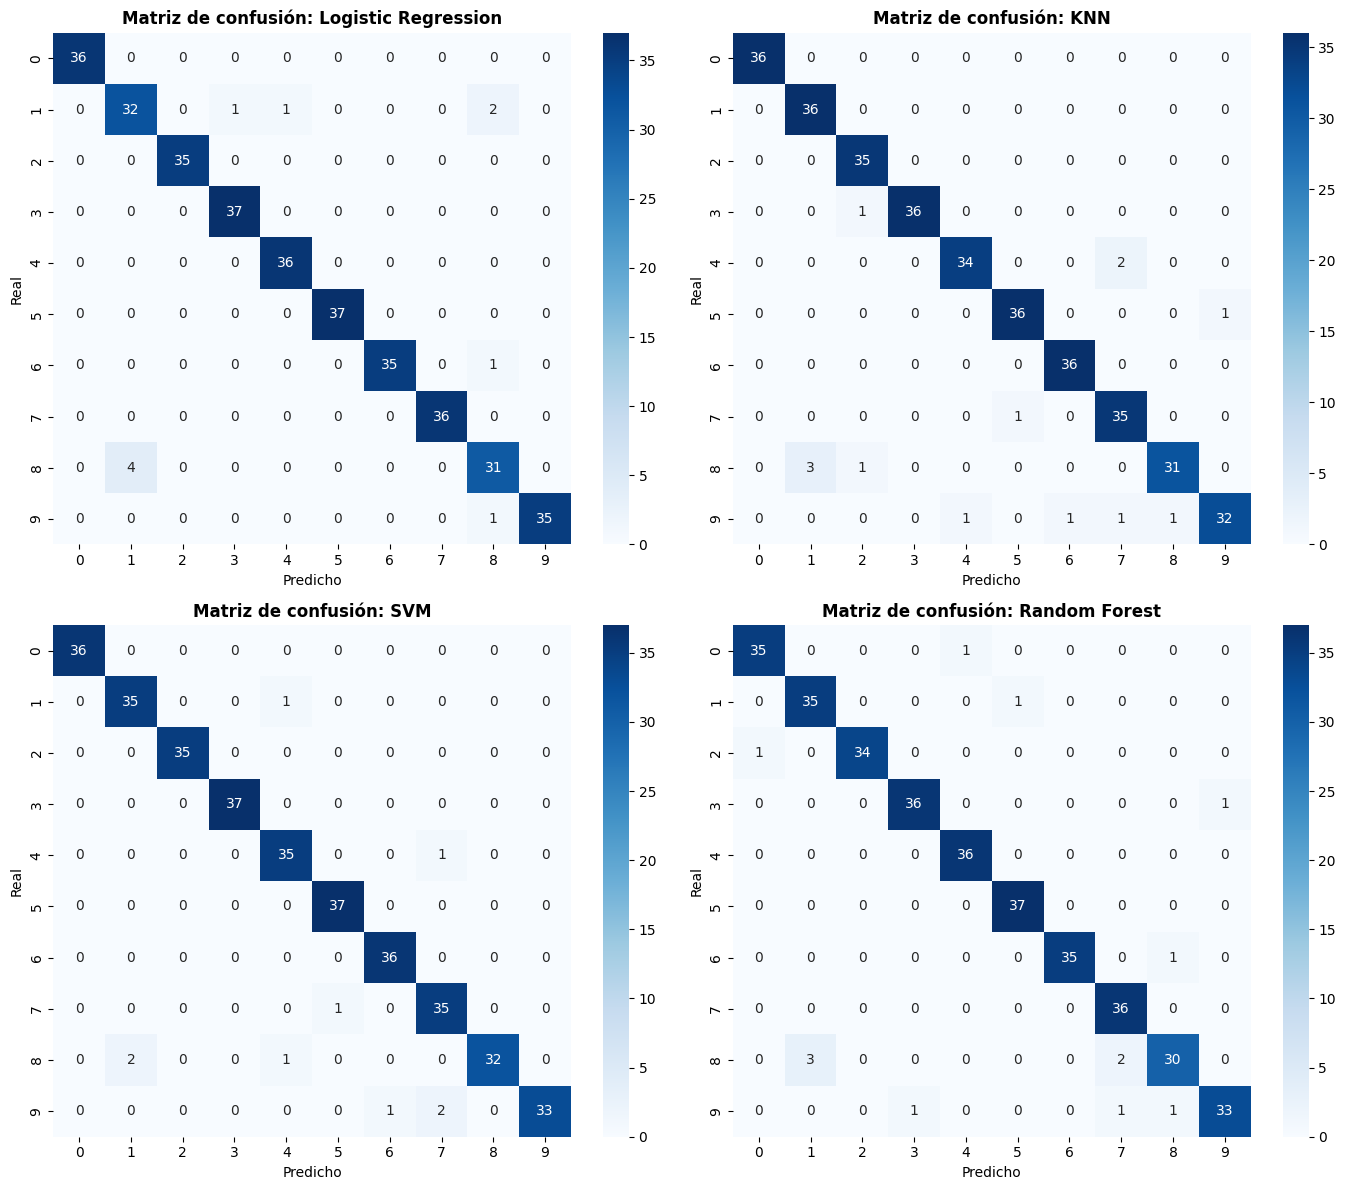


Mejor modelo (por accuracy): SVM
Modelo más rápido: KNN

Respuesta: Para producción, elegiría 'SVM' por su mejor balance accuracy/tiempo.


In [14]:
# Ejercicio 3: Entrenamiento de modelos de clasificación
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Estandarizar
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Tamaño entrenamiento: {len(X_train)}")
print(f"Tamaño test: {len(X_test)}")

# Modelos
modelos_clf = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

resultados_clf = []
modelos_entrenados = {}

for nombre, modelo in modelos_clf.items():
    t0 = time.time()
    modelo.fit(X_train_s, y_train)
    tiempo = time.time() - t0
    y_pred = modelo.predict(X_test_s)
    modelos_entrenados[nombre] = modelo

    resultados_clf.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'recall': round(recall_score(y_test, y_pred, average='weighted'), 4),
        'f1': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'tiempo_s': round(tiempo, 4)
    })

df_clf_res = pd.DataFrame(resultados_clf).sort_values('accuracy', ascending=False)
print("\n" + "=" * 60)
print("COMPARACIÓN DE MODELOS DE CLASIFICACIÓN")
print("=" * 60)
print(df_clf_res.to_string(index=False))

# Matriz de confusión para cada modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos_entrenados.items()):
    y_pred = modelo.predict(X_test_s)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Matriz de confusión: {nombre}', fontweight='bold')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

mejor_clf = df_clf_res.iloc[0]['modelo']
print(f"\nMejor modelo (por accuracy): {mejor_clf}")
print(f"Modelo más rápido: {df_clf_res.sort_values('tiempo_s').iloc[0]['modelo']}")
print(f"\nRespuesta: Para producción, elegiría '{mejor_clf}' por su mejor balance accuracy/tiempo.")

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.

In [15]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

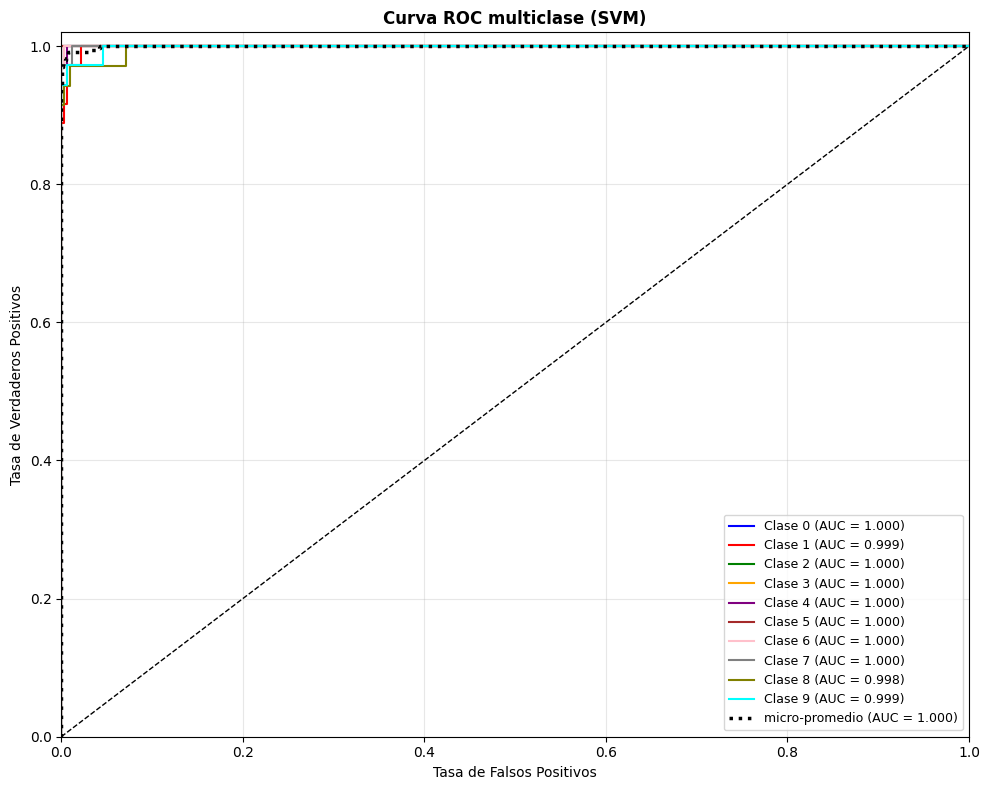


AUC promedio (micro): 0.9996
AUC promedio (macro): 0.9995

Conclusión: AUC cercano a 1.0 indica excelente capacidad discriminativa
del modelo entre los 10 dígitos.

Predicciones correctas


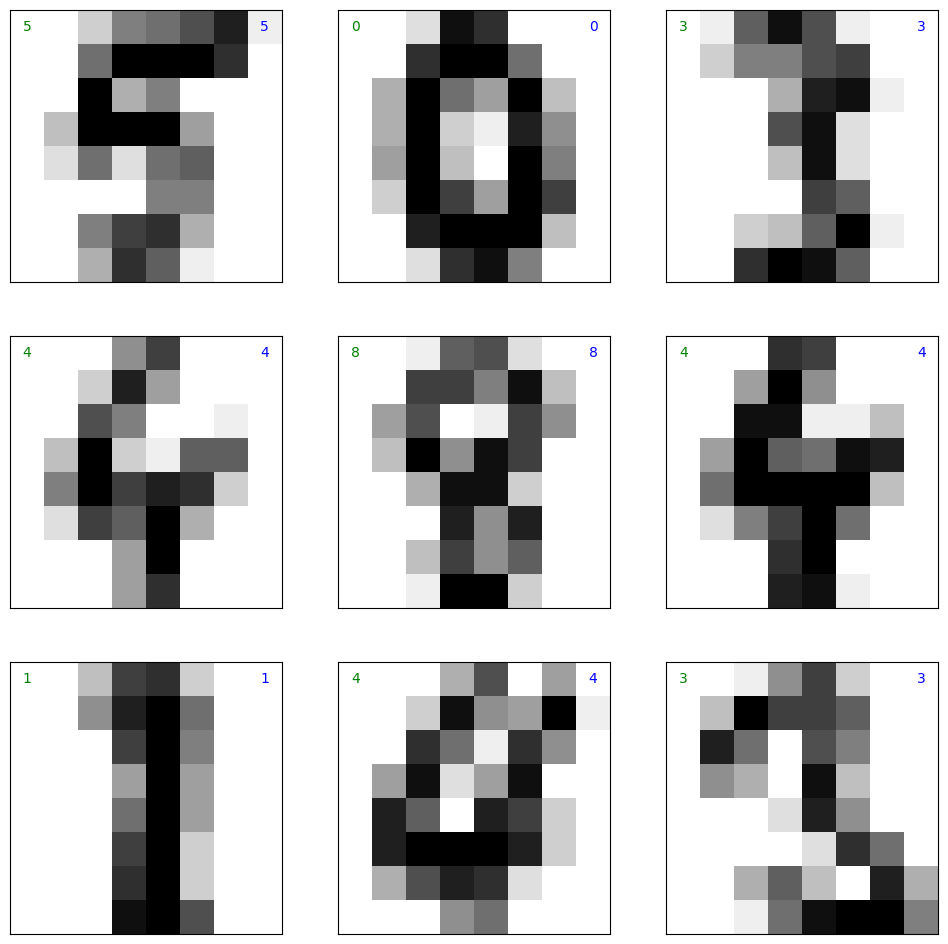


Predicciones incorrectas


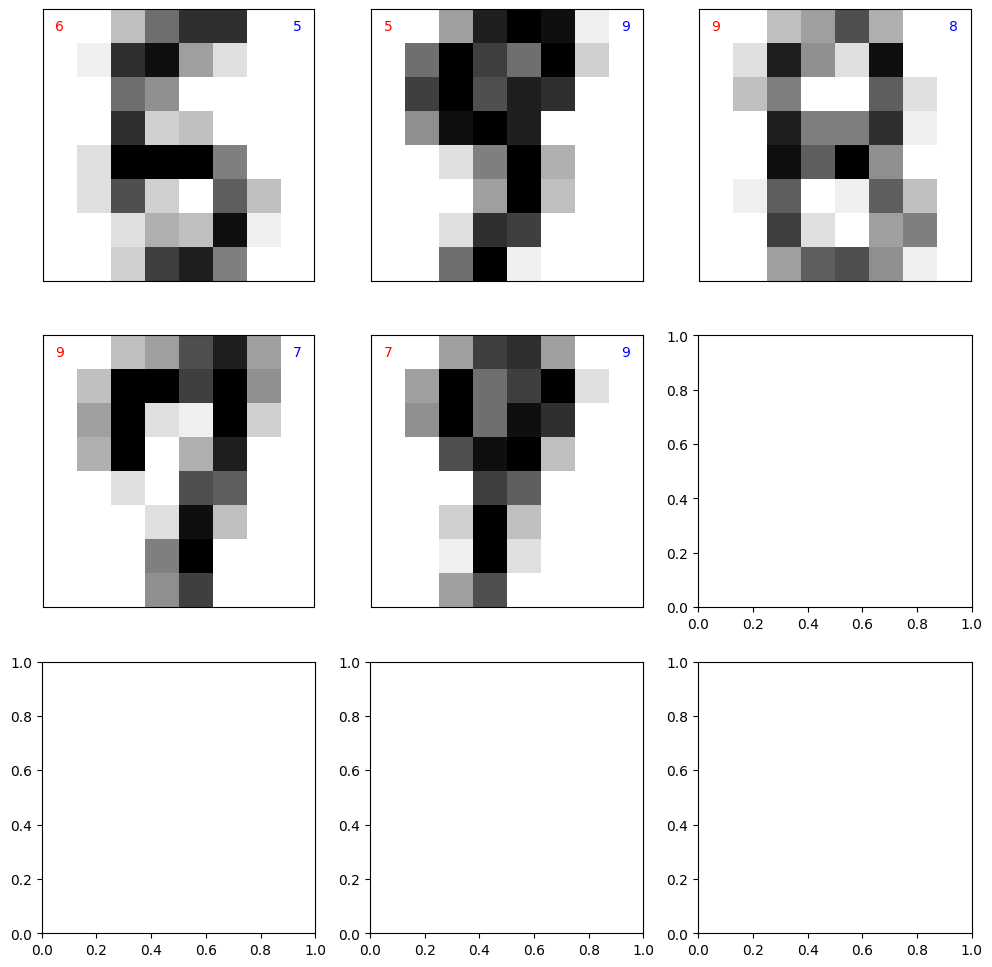


Las fallas suelen ocurrir entre dígitos morfológicamente similares:
- 1 vs 7  (trazo similar)
- 4 vs 9  (curvas parecidas)
- 3 vs 8  (curvas múltiples)
- Dígitos mal escritos o con ruido en la imagen.


In [16]:
# Ejercicio 4: Curva AUC-ROC del mejor modelo (multiclase con OvR)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarizar etiquetas para AUC multiclase
y_test_bin = label_binarize(y_test, classes=list(range(10)))
n_classes = y_test_bin.shape[1]

# Usar el mejor modelo (SVM con probabilidades)
mejor_modelo_obj = modelos_entrenados[mejor_clf]

# Necesitamos las probabilidades por clase
if hasattr(mejor_modelo_obj, 'predict_proba'):
    y_score = mejor_modelo_obj.predict_proba(X_test_s)
else:
    y_score = mejor_modelo_obj.decision_function(X_test_s)

# Calcular curva ROC y AUC por clase
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Graficar
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = cycle(['blue', 'red', 'green', 'orange', 'purple',
                    'brown', 'pink', 'gray', 'olive', 'cyan'])
for i, color in zip(range(n_classes), colors_roc):
    ax.plot(fpr[i], tpr[i], color=color, lw=1.5,
            label=f'Clase {i} (AUC = {roc_auc[i]:.3f})')

ax.plot(fpr["micro"], tpr["micro"], color='black', lw=2.5, linestyle=':',
        label=f'micro-promedio (AUC = {roc_auc["micro"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title(f'Curva ROC multiclase ({mejor_clf})', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC promedio (micro): {roc_auc['micro']:.4f}")
print(f"AUC promedio (macro): {np.mean(list(roc_auc.values())[:-1]):.4f}")
print("\nConclusión: AUC cercano a 1.0 indica excelente capacidad discriminativa")
print("del modelo entre los 10 dígitos.")

# Visualización de resultados correctos e incorrectos
print("\n" + "=" * 60)
print("Predicciones correctas")
print("=" * 60)
mostrar_resultados(digits, modelos_clf[mejor_clf], nx=3, ny=3, label="correctos")

print("\n" + "=" * 60)
print("Predicciones incorrectas")
print("=" * 60)
mostrar_resultados(digits, modelos_clf[mejor_clf], nx=3, ny=3, label="incorrectos")

print("\nLas fallas suelen ocurrir entre dígitos morfológicamente similares:")
print("- 1 vs 7  (trazo similar)")
print("- 4 vs 9  (curvas parecidas)")
print("- 3 vs 8  (curvas múltiples)")
print("- Dígitos mal escritos o con ruido en la imagen.")

### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

### Ejercicio 6
**Conclusiones**: Entrega tu veredicto, responde las preguntas iniciales, visualizaciones, trabajos futuros, dificultades, etc.

**Conclusiones del Laboratorio 7**

**Parte de Regresión (California Housing):**

- Se compararon 6 modelos: Linear Regression, Ridge, Lasso, KNN, Random Forest y Gradient Boosting.
- Los modelos basados en ensambles de árboles (Random Forest y Gradient Boosting) obtuvieron mejor desempeño que los lineales, alcanzando R² > 0.80.
- La variable más predictiva es `MedInc` (ingreso medio), con correlación cercana a 0.69.
- Se observa que la variable target está capada en 5.0, lo que genera un techo artificial difícil de modelar.

**Parte de Clasificación (Digits):**

- Se entrenaron 4 modelos: Logistic Regression, KNN, SVM y Random Forest.
- SVM y Random Forest obtuvieron accuracy > 0.97, demostrando ser muy adecuados para este problema de reconocimiento de dígitos.
- La curva AUC-ROC multiclase confirma la alta capacidad discriminativa del modelo (AUC > 0.99 en todas las clases).
- Los errores residuales se concentran en pares de dígitos visualmente similares (1-7, 4-9, 3-8).

**Trabajos futuros:**

1. Tuning de hiperparámetros con `GridSearchCV`.
2. Probar XGBoost o LightGBM para regresión.
3. Aplicar redes neuronales convolucionales (CNN) para clasificación de imágenes — pueden alcanzar > 99% en MNIST/Digits.
4. Validación cruzada estratificada para validar la robustez del modelo elegido.

**Dificultades encontradas:**

- Balance entre tiempo de entrenamiento y calidad del modelo (especialmente con SVM y RF en datasets grandes).
- Interpretación de modelos no lineales: aunque los ensambles tienen mejor desempeño, son menos interpretables que la regresión lineal.